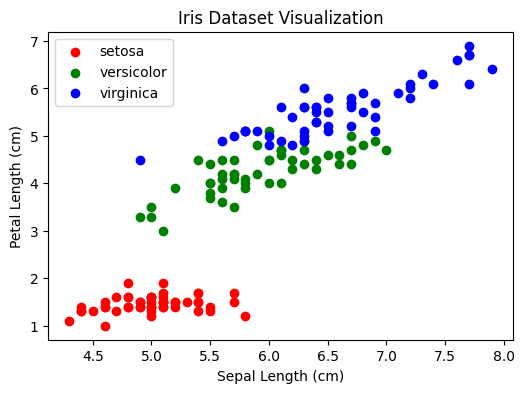

Accuracy: 0.9666666666666667
Confusion Matrix:
 [[10  0  0]
 [ 0  8  1]
 [ 0  0 11]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.89      0.94         9
           2       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30



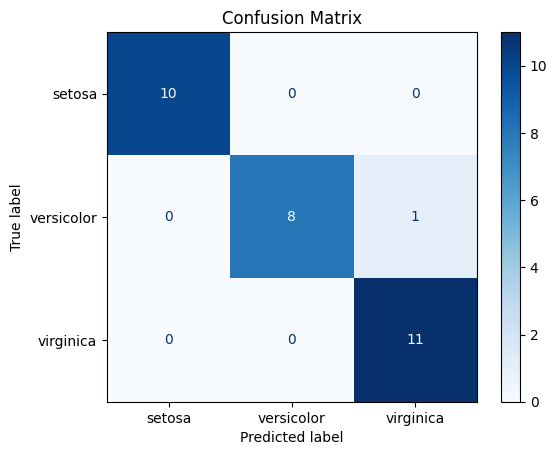

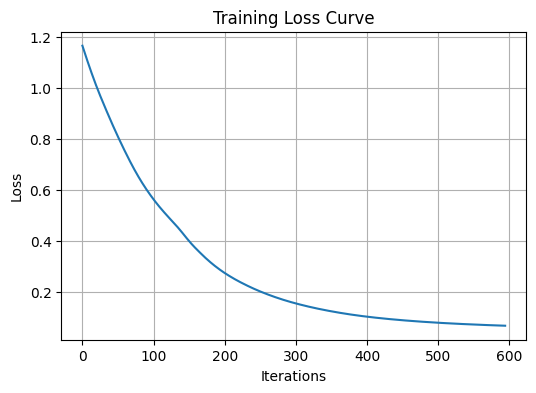

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# Load Dataset
iris = load_iris()
X, y = iris.data, iris.target

# Data Visualization

df = pd.DataFrame(X, columns=iris.feature_names)
df["Species"] = y

plt.figure(figsize=(6,4))

colors = ['red', 'green', 'blue']

for i in range(3):
    plt.scatter(
        df[df["Species"] == i]["sepal length (cm)"],
        df[df["Species"] == i]["petal length (cm)"],
        color=colors[i],
        label=iris.target_names[i]
    )

plt.title("Iris Dataset Visualization")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Petal Length (cm)")
plt.legend()
plt.show()

# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ANN Model

mlp = MLPClassifier(
    hidden_layer_sizes=(10,10),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42
)

# Train Model
mlp.fit(X_train, y_train)

# Prediction
y_pred = mlp.predict(X_test)

# Evaluation

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix Visualization

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=iris.target_names,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

# Loss Curve

plt.figure(figsize=(6,4))
plt.plot(mlp.loss_curve_)
plt.title("Training Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


In [ ]:
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

In [ ]:
wine = datasets.load_wine()
X = wine.data
y = wine.target

# First scenario: 70% training, 30% test
X_train1, X_test1, y_train1, y_test1 = train_test_split(X, y, test_size=0.3, random_state=42)

# Second scenario: 90% training, 10% test
X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, test_size=0.1, random_state=42)

# MLP1 100-100
mlp1 = MLPClassifier(hidden_layer_sizes=(100, 100), max_iter=2000, learning_rate_init=0.001, random_state=42)

# MLP2 50-
mlp2 = MLPClassifier(hidden_layer_sizes=(50,), max_iter=2000, learning_rate_init=0.001, random_state=42)


In [ ]:
def calculate_and_plot_metrics(X_train, y_train, X_test, y_test, title):
    mlp1.fit(X_train, y_train)
    y_pred_mlp1 = mlp1.predict(X_test)

    mlp2.fit(X_train, y_train)
    y_pred_mlp2 = mlp2.predict(X_test)

    # Calculate metrics
    def calculate_metrics(y_true, y_pred):
        accuracy = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average='weighted')
        precision = precision_score(y_true, y_pred, average='weighted', zero_division=1)
        recall = recall_score(y_true, y_pred, average='weighted')
        return accuracy, f1, precision, recall

    # Metrics for MLP1
    accuracy_mlp1, f1_mlp1, precision_mlp1, recall_mlp1 = calculate_metrics(y_test, y_pred_mlp1)

    # Metrics for MLP2
    accuracy_mlp2, f1_mlp2, precision_mlp2, recall_mlp2 = calculate_metrics(y_test, y_pred_mlp2)

    # Confusion Matrix and Visualization (MLP1)
    cm_mlp1 = confusion_matrix(y_test, y_pred_mlp1)
    disp_mlp1 = ConfusionMatrixDisplay(confusion_matrix=cm_mlp1, display_labels=wine.target_names)
    fig, axes = plt.subplots(2, 2, figsize=(7, 7))
    disp_mlp1.plot(cmap='viridis', values_format='d', ax=axes[0, 0])
    axes[0, 0].set_title("MLP1 Confusion Matrix")

    # Loss Curve (MLP1)
    axes[0, 1].plot(mlp1.loss_curve_)
    axes[0, 1].set_title("MLP1 Loss Curve")
    axes[0, 1].set_xlabel('Iterations')
    axes[0, 1].set_ylabel('Cost')

    # Confusion Matrix and Visualization (MLP2)
    cm_mlp2 = confusion_matrix(y_test, y_pred_mlp2)
    disp_mlp2 = ConfusionMatrixDisplay(confusion_matrix=cm_mlp2, display_labels=wine.target_names)
    disp_mlp2.plot(cmap='viridis', values_format='d', ax=axes[1, 0])
    axes[1, 0].set_title("MLP2 Confusion Matrix")

    # Loss Curve (MLP2)
    axes[1, 1].plot(mlp2.loss_curve_)
    axes[1, 1].set_title("MLP2 Loss Curve")
    axes[1, 1].set_xlabel('Iterations')
    axes[1, 1].set_ylabel('Cost')

    # Calculate 10-fold cross-validation results
    cross_val_scores1_mlp1 = cross_val_score(mlp1, X_train, y_train, cv=10, scoring='f1_weighted')
    cross_val_scores1_mlp2 = cross_val_score(mlp2, X_train, y_train, cv=10, scoring='f1_weighted')

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

    return accuracy_mlp1, f1_mlp1, precision_mlp1, recall_mlp1, accuracy_mlp2, f1_mlp2, precision_mlp2, recall_mlp2, cross_val_scores1_mlp1, cross_val_scores1_mlp2

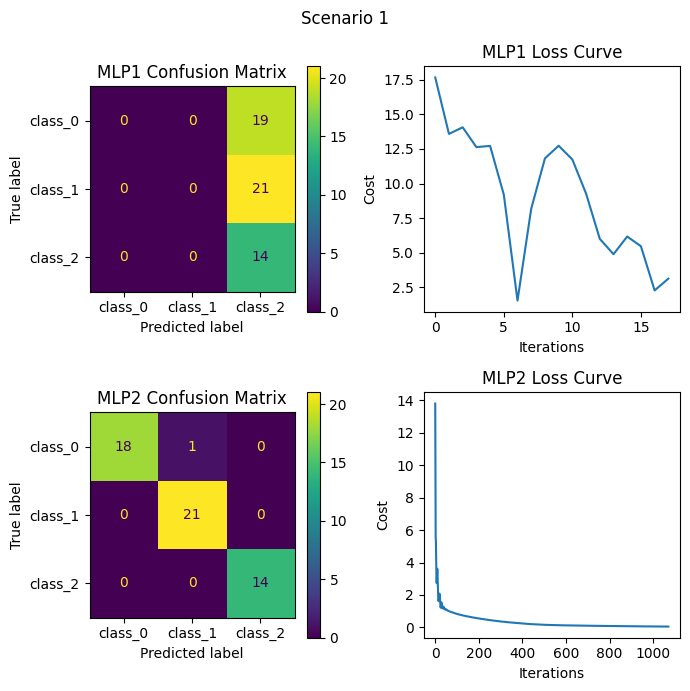

Scenario 1 (MLP1):
Accuracy: 0.2593
F1 Score: 0.1068
Precision: 0.8080
Recall: 0.2593

Scenario 1 (MLP2):
Accuracy: 0.9815
F1 Score: 0.9814
Precision: 0.9823
Recall: 0.9815

Scenario 1 10-Fold Cross-Validation (MLP1) F1 Score: 0.2315341521223874
Scenario 1 10-Fold Cross-Validation (MLP2) F1 Score: 0.9346122396122396


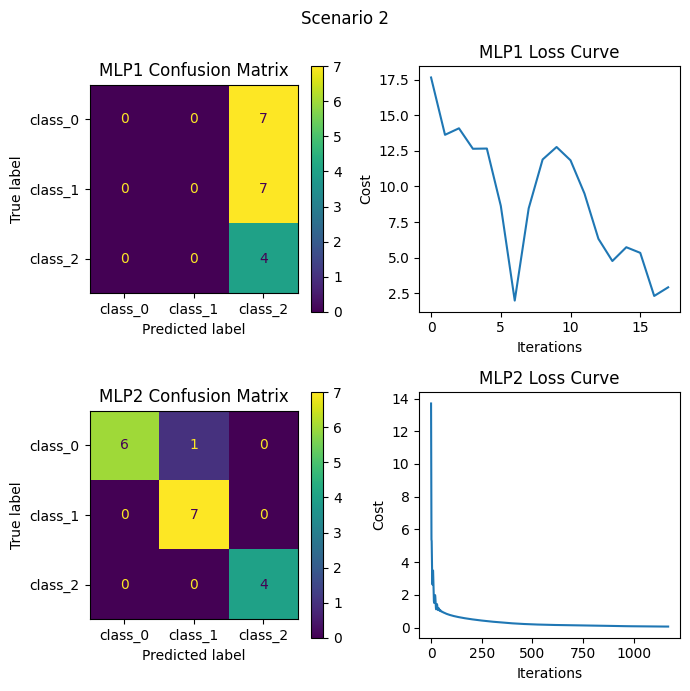

Scenario 2 (MLP1):
Accuracy: 0.2222
F1 Score: 0.0808
Precision: 0.8272
Recall: 0.2222

Scenario 2 (MLP2):
Accuracy: 0.9444
F1 Score: 0.9442
Precision: 0.9514
Recall: 0.9444

Scenario 2 10-Fold Cross-Validation (MLP1) F1 Score: 0.22674655388471177
Scenario 2 10-Fold Cross-Validation (MLP2) F1 Score: 0.9561985236985237
Comparison:
Scenario 1 (MLP1) Accuracy - Scenario 2 (MLP1) Accuracy: 0.037037037037037035
Scenario 1 (MLP2) Accuracy - Scenario 2 (MLP2) Accuracy: 0.03703703703703709
Scenario 1 (MLP1) F1 Score - Scenario 2 (MLP1) F1 Score: 0.025945731828084767
Scenario 1 (MLP2) F1 Score - Scenario 2 (MLP2) F1 Score: 0.03728701868236739


In [ ]:
# Calculations for Scenario 1
accuracy1_mlp1, f1_1_mlp1, precision1_mlp1, recall1_mlp1, accuracy1_mlp2, f1_1_mlp2, precision1_mlp2, recall1_mlp2, cross_val_scores1_mlp1, cross_val_scores1_mlp2 = calculate_and_plot_metrics(X_train1, y_train1, X_test1, y_test1, "Scenario 1")

# Outputs for Scenario 1
print("Scenario 1 (MLP1):")
print(f"Accuracy: {accuracy1_mlp1:.4f}\nF1 Score: {f1_1_mlp1:.4f}\nPrecision: {precision1_mlp1:.4f}\nRecall: {recall1_mlp1:.4f}\n")
print("Scenario 1 (MLP2):")
print(f"Accuracy: {accuracy1_mlp2:.4f}\nF1 Score: {f1_1_mlp2:.4f}\nPrecision: {precision1_mlp2:.4f}\nRecall: {recall1_mlp2:.4f}\n")
print("Scenario 1 10-Fold Cross-Validation (MLP1) F1 Score:", np.mean(cross_val_scores1_mlp1))
print("Scenario 1 10-Fold Cross-Validation (MLP2) F1 Score:", np.mean(cross_val_scores1_mlp2))

# Calculations for Scenario 2
accuracy2_mlp1, f1_2_mlp1, precision2_mlp1, recall2_mlp1, accuracy2_mlp2, f1_2_mlp2, precision2_mlp2, recall2_mlp2, cross_val_scores2_mlp1, cross_val_scores2_mlp2 = calculate_and_plot_metrics(X_train2, y_train2, X_test2, y_test2, "Scenario 2")

# Outputs for Scenario 2
print("Scenario 2 (MLP1):")
print(f"Accuracy: {accuracy2_mlp1:.4f}\nF1 Score: {f1_2_mlp1:.4f}\nPrecision: {precision2_mlp1:.4f}\nRecall: {recall2_mlp1:.4f}\n")
print("Scenario 2 (MLP2):")
print(f"Accuracy: {accuracy2_mlp2:.4f}\nF1 Score: {f1_2_mlp2:.4f}\nPrecision: {precision2_mlp2:.4f}\nRecall: {recall2_mlp2:.4f}\n")
print("Scenario 2 10-Fold Cross-Validation (MLP1) F1 Score:", np.mean(cross_val_scores2_mlp1))
print("Scenario 2 10-Fold Cross-Validation (MLP2) F1 Score:", np.mean(cross_val_scores2_mlp2))

# Scenario 1 and Scenario 2 comparison
print("Comparison:")
print("Scenario 1 (MLP1) Accuracy - Scenario 2 (MLP1) Accuracy:", accuracy1_mlp1 - accuracy2_mlp1)
print("Scenario 1 (MLP2) Accuracy - Scenario 2 (MLP2) Accuracy:", accuracy1_mlp2 - accuracy2_mlp2)
print("Scenario 1 (MLP1) F1 Score - Scenario 2 (MLP1) F1 Score:", f1_1_mlp1 - f1_2_mlp1)
print("Scenario 1 (MLP2) F1 Score - Scenario 2 (MLP2) F1 Score:", f1_1_mlp2 - f1_2_mlp2)